# Exploring the PEFT Library

Out of interest in understanding the library, I decided to work with the pre-trained [ruT5](https://habr.com/ru/company/sberbank/blog/567776/) model, pre-trained in the `SCO`-format for data generation.

I'll try to further train it on news texts from [Газета.Ru](https://www.kaggle.com/datasets/phoenix120/gazeta-summaries) for the task of abstract news summarization. We'll not only train the entire model but also try applying some parameter-efficient training approaches using the PEFT library.

In [ ]:
%pip install -q datasets transformers sentencepiece peft evaluate rouge_score accelerate tiktoken protobuf

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import json

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset, load_dataset
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    IA3Config
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    T5ForConditionalGeneration,
    Trainer,
    TrainingArguments,
)

import time
import copy

sns.set_theme(font_scale=1.2, palette="Set2")

In [ ]:
# chart style parameters
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['grid.color'] = '#dddddd'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.alpha'] = 0.6
plt.rcParams['axes.edgecolor'] = '#666666'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

Let's look at an example of generation using `ruT5-base` for a denoising task:

In [ ]:
model = T5ForConditionalGeneration.from_pretrained("ai-forever/ruT5-base")
tokenizer = AutoTokenizer.from_pretrained("ai-forever/ruT5-base")

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
input_ids = tokenizer(
    "Снижение цен <extra_id_0> в Москве возможно только при <extra_id_1> "
    + "Это условие названо в аналитической заметке портала Новости <extra_id_2> ",
    return_tensors="pt",
)["input_ids"]

out_ids = model.generate(
    input_ids=input_ids, # sequence of input tokens, in our case the decoder input
    decoder_start_token_id=tokenizer.pad_token_id,
    max_length=64,  # max length of generated sequence
    eos_token_id=tokenizer.eos_token_id,  # eos токен
    num_beams=5, # specify num_beams - beam_search will be used
)

tokenizer.decode(out_ids[0])

'<pad><extra_id_0> на жилье<extra_id_1> соблюдении ряда условий.<extra_id_2> Москвы</s>'

Interestingly, the role of the bos token here is played by the `<pad>`. Further, the gaps in `<extra_id_X>` are expanded into possible text fragments. In this case, `<extra_id_0>`, `<extra_id_1>`, etc. are special tokens that the model must fill in, thereby solving the denoising problem. Since T5 is a full-fledged transformer, the encoder input during pretraining is text with these special tokens, and the decoder input is the sequences that should replace the special tokens.

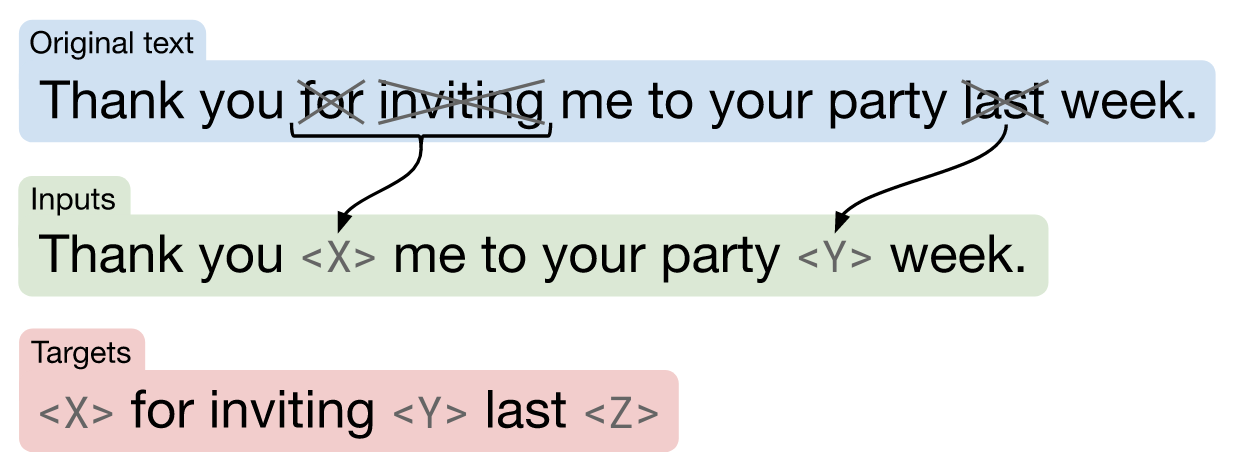

### 1. Data preprocessing

In [ ]:
from datasets import load_dataset

base_url = "https://huggingface.co/datasets/IlyaGusev/gazeta/resolve/v1.0/"

data_files = {
    "train": base_url + "gazeta_train.jsonl",
    "test": base_url + "gazeta_test.jsonl",
    "validation": base_url + "gazeta_val.jsonl",
}

dataset = load_dataset("json", data_files=data_files)

In [ ]:
train_data = dataset['train'].select(range(5000))
val_data = dataset['validation'].select(range(500))

Let's look at what the training example consists of. We'll be interested in the `text` and `summary` fields:

In [ ]:
train_data[13]

{'url': 'https://www.gazeta.ru/culture/2019/04/30/a_12331549.shtml',
 'text': 'Российскому певцу Андрею Губину исполнилось 45 лет. Последнее время артист залег на дно и перестал радовать поклонников новыми хитами и полностью отказался от концертов. В одном из немногочисленных интервью, Губин жаловался на свое здоровье, указывая на проблемы нервной системы. По словам музыканта, врачи не уделили ему должного внимания, в связи с чем ему приходится бороться с проблемой самостоятельно. Продюсер «Ласкового мая» Андрей Разин рассказал о том, что он пытается помочь Губину. Разин подтвердил, что у звезды 90-х действительно серьезные проблемы, однако, по его мнению, это проблемы психического характера: «У Андрея серьезные проблемы с психикой. Ему мерещится, что у него постоянно чешется и болит лицо. Мы его водили по врачам, они ничего не нашли». Он также отметил, что с певцом стало очень тяжело говорить, поскольку тот стал чрезмерно вспыльчивым и ранимым, неадекватно воспринимая все попытки ему 

Select the required fields:

In [ ]:
train_text = train_data['text']
train_summary = train_data['summary']

val_text = val_data['text']
val_summary = val_data['summary']

Collect datasets:

In [ ]:
train_dataset = Dataset.from_dict({"text": train_text, "summary": train_summary})

val_dataset = Dataset.from_dict({"text": val_text, "summary": val_summary})

Let's write a function to preprocess our data. Architecturally, the `ruT5` model is a full-fledged transformer. The model will receive the source text of a news story as input, from which it will attempt to generate a compressed summary.

In [ ]:
def preprocess_function(examples):
    """
    Функция препроцессинга для обработки данных.
    """

    # выделим input / targets для модели
    inputs = examples["text"]
    targets = examples["summary"]

    # токенизируем новости, это вход энкодера
    # наша source-последовательность
    model_inputs = tokenizer(
        inputs,
        max_length=600,
        truncation=True,
    )

    # токенизируем саммари, это вход декодера во время обучения
    # то есть наша target-последовательность
    labels = tokenizer(
        text_target=targets,
        max_length=200,
        truncation=True,
    )

    # labels для модели
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

I apply preprocessing to the dataset. Note that padding is now performed **dynamically** during batch generation using `DataCollatorForSeq2Seq`. This is much more efficient than padding all examples to the maximum length in advance.

In [ ]:
train_dataset = train_dataset.map(
    preprocess_function,
    batched=True,
    num_proc=2,
    desc="Running tokenizer on train dataset...",
)

val_dataset = val_dataset.map(
    preprocess_function,
    batched=True,
    num_proc=2,
    desc="Running tokenizer on val dataset...",
)

Running tokenizer on train dataset... (num_proc=2):   0%|          | 0/5000 [00:00<?, ? examples/s]

Running tokenizer on val dataset... (num_proc=2):   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

### 2. Training models

The [`PEFT`](https://github.com/huggingface/peft) presents various approaches to parameter-efficient learning. I'll discuss two of the most popular:

#### $LoRA$ - Low-Rank Adaptation of Large Language Models


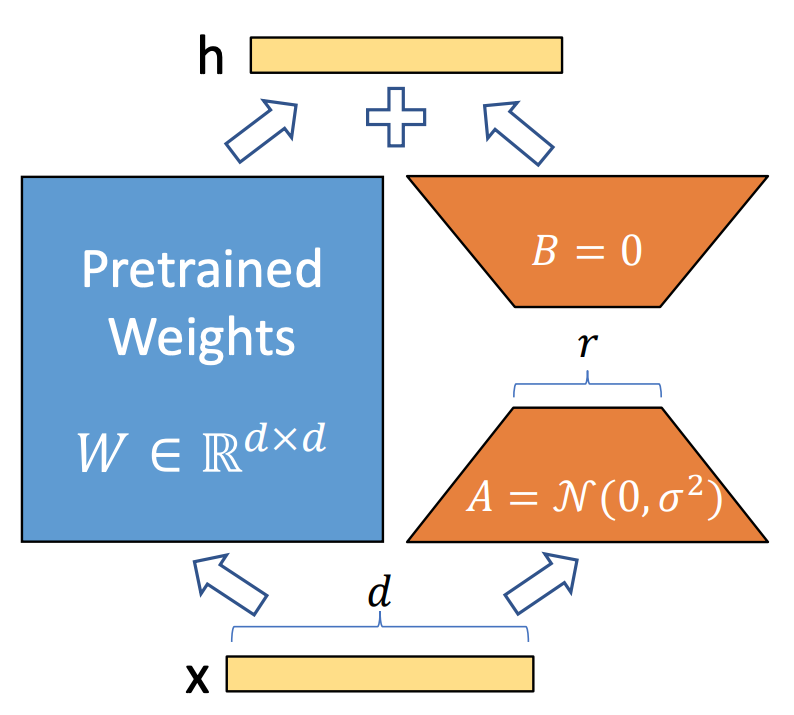


Allows to improve training efficiency by using low-rank approximation for matrices.

#### $(IA)^{3}$ - Infused Adapter by Inhibiting and Amplifying Inner Activations


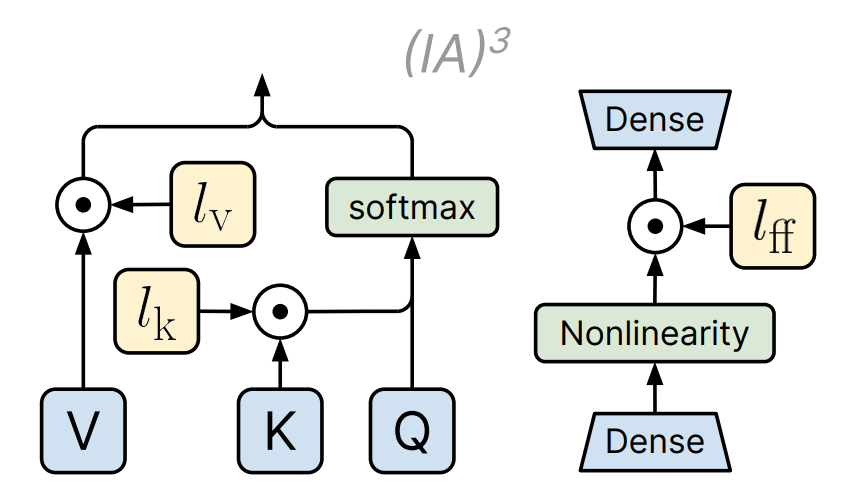


The $(IA)^{3}$ method adds trainable vectors $l_v$, $l_k$, and $l_{ff}$ to the model, which are multiplied (element-wise) by the corresponding outputs of the model layers, thereby achieving trainable rescaling. Model training with this adapter is even more efficient than training using $LoRA$, and the results are comparable to conventional fine-tuning (we'll verify this).

Let's train models using the methods described above and compare them with conventional fine-tuning of the model. Consider:

* Full fine-tuning;

* $LoRA$ ($r = 4$, $\alpha=16$, inject in $[q, v]$);

* $LoRA$ ($r = 16$, $\alpha=16$, inject in $[q, v]$);

* custom $LoRA$ ($r = 4$, $\alpha=16$, inject in $[q, v]$);

* custom $LoRA$ ($r = 4$, $\alpha=16$, inject in $[q, k, v]$);

* $(IA)^{3}$ ($r = 4$, $\alpha=16$, inject in $[k, v]$);

* $(IA)^{3}$ ($r = 4$, $\alpha=16$, inject in $[k, v, wo]$);


We start with our own implementation of the $LoRA$ adapter:

In [ ]:
class LoRALayerWrapper(nn.Module):
    def __init__(self, original_layer, rank=8, alpha=16):
        super().__init__()
        self.original_layer = original_layer
        self.original_layer.requires_grad_(False)

        in_features = original_layer.in_features
        out_features = original_layer.out_features

        # Инициализация LoRA параметров
        self.lora_A = nn.Parameter(torch.empty(in_features, rank))
        self.lora_B = nn.Parameter(torch.empty(out_features, rank))
        self.scaling = alpha / rank

        # Инициализация весов
        nn.init.zeros_(self.lora_B)
        nn.init.normal_(self.lora_A, mean=0, std=0.02)


    def forward(self, input):
        x = self.original_layer(input)

        lora_output = (input @ self.lora_A) @ self.lora_B.T * self.scaling

        return x + lora_output

Let's check the implementation by comparing it with the one provided by `PEFT`:

In [ ]:
torch.manual_seed(42)
rank = 4
alpha = 32
dummy_input = torch.randn(1, 1, 768)

# Реализация через peft
peft_config = LoraConfig(
    r=rank,
    lora_alpha=alpha,
    target_modules=["q", "v"],
    lora_dropout=0.0,
    bias="none",
    task_type="SEQ_2_SEQ_LM",
)

base_model = T5ForConditionalGeneration.from_pretrained("ai-forever/ruT5-base")
peft_model = get_peft_model(base_model, peft_config)

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
# take one module for a simple test
q_layer_to_test = peft_model.base_model.encoder.block[0].layer[0].SelfAttention.q
# original linear layer
base_linear_layer = q_layer_to_test.base_layer
# our wrapper
our_model = LoRALayerWrapper(base_linear_layer, rank=rank, alpha=alpha)

our_output = our_model(dummy_input)
peft_output = q_layer_to_test(dummy_input)
assert torch.allclose(our_output, peft_output, atol=1e-4), (
    "Что-то не так с простым forward"
)

The test above is quite simple, since due to the initialization process, LoRA does nothing initially. Let's add a slightly more complex test case:

In [ ]:
dummy_B = torch.randn_like(our_model.lora_B.data)

with torch.no_grad():
    # copy the parameters
    our_model.lora_B.data.copy_(dummy_B)
    q_layer_to_test.lora_B.default.weight.data.copy_(dummy_B)
    our_model.lora_A.data.copy_(q_layer_to_test.lora_A.default.weight.data.T)

# forward + backward pass for implementations
our_output = our_model(dummy_input)
our_loss = our_output.sum()
our_loss.backward()

peft_output = q_layer_to_test(dummy_input)
peft_loss = peft_output.sum()
peft_loss.backward()


In [ ]:
our_grad_A = our_model.lora_A.grad
peft_grad_A = q_layer_to_test.lora_A.default.weight.grad.T

our_grad_B = our_model.lora_B.grad
peft_grad_B = q_layer_to_test.lora_B.default.weight.grad

assert torch.allclose(our_grad_A, peft_grad_A, atol=1e-4), (
    "Расхождения градиентов для матрицы A"
)
assert torch.allclose(our_grad_B, peft_grad_B, atol=1e-4), (
    "Расхождения градиентов для матрицы B"
)


Everything's great! Let's move on:

Now let's write a function to wrap modules `q`, `v` through the implemented layer:

In [ ]:
def inject_lora(model, rank, alpha):
    # enc qv
    for encoder_block in model.encoder.block:
        self_attn = encoder_block.layer[0].SelfAttention
        self_attn.q = LoRALayerWrapper(self_attn.q, rank, alpha)
        self_attn.v = LoRALayerWrapper(self_attn.v, rank, alpha)

    # dec qv
    for decoder_block in model.decoder.block:
        # Self attention
        self_attn = decoder_block.layer[0].SelfAttention
        self_attn.q = LoRALayerWrapper(self_attn.q, rank, alpha)
        self_attn.v = LoRALayerWrapper(self_attn.v, rank, alpha)

        # Cross attention
        cross_attn = decoder_block.layer[1].EncDecAttention
        cross_attn.q = LoRALayerWrapper(cross_attn.q, rank, alpha)
        cross_attn.v = LoRALayerWrapper(cross_attn.v, rank, alpha)

    # freeze all parameters, unfreeze only LoRA matrices
    for name, param in model.named_parameters():
        if 'lora_A' in name or 'lora_B' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    return model


Let's also add a version of the inject that adds the $LoRA$ adapter to all `q`, `k`, and `v` modules:

In [ ]:
def inject_lora_full(model, rank, alpha):
    # enc qkv
    for encoder_block in model.encoder.block:
        self_attn = encoder_block.layer[0].SelfAttention

        self_attn.q = LoRALayerWrapper(self_attn.q, rank, alpha)
        self_attn.k = LoRALayerWrapper(self_attn.k, rank, alpha)
        self_attn.v = LoRALayerWrapper(self_attn.v, rank, alpha)

    # dec qkv
    for decoder_block in model.decoder.block:
        self_attn = decoder_block.layer[0].SelfAttention

        self_attn.q = LoRALayerWrapper(self_attn.q, rank, alpha)
        self_attn.k = LoRALayerWrapper(self_attn.k, rank, alpha)
        self_attn.v = LoRALayerWrapper(self_attn.v, rank, alpha)

        cross_attn = decoder_block.layer[1].EncDecAttention

        cross_attn.q = LoRALayerWrapper(cross_attn.q, rank, alpha)
        cross_attn.k = LoRALayerWrapper(cross_attn.k, rank, alpha)
        cross_attn.v = LoRALayerWrapper(cross_attn.v, rank, alpha)

    # freeze all parameters, unfreeze only LoRA matrices
    for name, param in model.named_parameters():
        if 'lora_A' in name or 'lora_B' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    return model

Knowing that PEFT methods, which are designed for efficient fine-tuning of models, rely on fewer trainable parameters, we can safely assume that the key difference between the approaches will not only be a more rapid reduction in loss and an increase in metrics, but also a direct effect on the number of trainable parameters. Therefore, let's create the function `train_params_cnt(model)`:

In [ ]:
def train_params_cnt(model):
  return sum(param.numel() for param in model.parameters() if param.requires_grad)



Let's define a common `Trainer` for all models:

In [ ]:
from transformers import TrainerCallback

training_args = TrainingArguments(
    output_dir="./model_outputs",
    num_train_epochs=2,
    eval_strategy="epoch",
    logging_strategy="epoch"
)

class MetricsHistoryCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.epochs = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            if 'loss' in logs:
                self.train_losses.append(logs['loss'])
            if 'eval_loss' in logs:
                self.val_losses.append(logs['eval_loss'])
                if state.epoch is not None:
                    self.epochs.append(state.epoch)


def run_model(model, name):
    """
    This function trains the model by calculating training time and metrics.
    """
    history_callback = MetricsHistoryCallback()

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        processing_class=tokenizer,
        callbacks=[history_callback]
    )

    time_start = time.time()
    trainer.train()
    time_finish = time.time() - time_start

    metrics = trainer.evaluate()

    return {
        "model": name,
        "all_trained_params": train_params_cnt(model),
        "train_time": time_finish,
        "train_loss": metrics.get("train_loss", None),  # final train loss
        "val_loss": metrics["eval_loss"],  # final val loss
        "train_loss_history": history_callback.train_losses,  # history of train loss by steps
        "val_loss_history": history_callback.val_losses,  # history of val loss by epochs
        "epochs_history": history_callback.epochs  # num of epochs for val loss
    }



##### 2.1. Fully fine-tuned model without PEFT methods:

In [ ]:
import torch
import gc

torch.cuda.empty_cache()
gc.collect()

10245

In [ ]:
model_results = []

In [ ]:
model_fft = model

model_results.append(run_model(model_fft, "full fine-tuned"))
torch.save(model_fft.state_dict(), "/kaggle/working/model_FFT_weights.pth")

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,5.974694,4.221310
2,5.153651,4.177839


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


In [ ]:
model_results

[{'model': 'full fine-tuned',
  'all_trained_params': 296926464,
  'train_time': 1240.2154235839844,
  'train_loss': None,
  'val_loss': 4.177839279174805,
  'train_loss_history': [5.974694005216653, 5.153651423347644],
  'val_loss_history': [4.221310138702393,
   4.177839279174805,
   4.177839279174805],
  'epochs_history': [1.0, 2.0, 2.0]}]

##### 2.2.1. $LoRA$ ($r = 4$, $\alpha=16$, inject in $[q, v]$)

##### 2.2.2. $LoRA$ ($r = 16$, $\alpha=16$, inject in $[q, v]$)

In [ ]:
torch.cuda.empty_cache()
gc.collect()

model_2 = model

# LoRA (r = 4)
peft_config_4 = LoraConfig(
    r=4,
    lora_alpha=16,
    target_modules=["q", "v"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
)

model_LoRA_peft_4 = get_peft_model(model_2, peft_config_4)

model_results.append(run_model(model_LoRA_peft_4, f"fine-tuned with LoRA r = 4"))
torch.save(model_LoRA_peft_4.state_dict(), "/kaggle/working/model_LoRA_peft_4_weights.pth")

torch.cuda.empty_cache()
gc.collect()

model_3 = model

# LoRA (r = 16)
peft_config_16 = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q", "v"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
)

model_LoRA_peft_16 = get_peft_model(model_3, peft_config_16)

model_results.append(run_model(model_LoRA_peft_16, f"fine-tuned with LoRA r = 16"))
torch.save(model_LoRA_peft_16.state_dict(), "/kaggle/working/model_LoRA_peft_16_weights.pth")


Epoch,Training Loss,Validation Loss
1,5.032266,4.187055
2,5.033597,4.185073


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,5.032350,4.187292
2,5.033570,4.185302


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


##### 2.3.1. custom $LoRA$ ($r = 4$, $\alpha=16$, inject in $[q, v]$)

In [ ]:
torch.cuda.empty_cache()
gc.collect()

model_4 = model

model_LoRA_custom_qv = inject_lora(model_4, rank=4, alpha=16)

model_results.append(run_model(model_LoRA_custom_qv, "fine-tuned with my LoRA (r = 4) on qv"))
torch.save(model_LoRA_custom_qv.state_dict(), "/kaggle/working/model_LoRA_custom_qv_weights.pth")


Epoch,Training Loss,Validation Loss
1,5.016494,4.187154
2,5.021367,4.180439


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


##### 2.3.2. custom $LoRA$ ($r = 4$, $\alpha=16$, inject in $[q, k, v]$)

In [ ]:
torch.cuda.empty_cache()
gc.collect()

model_5 = model

model_LoRA_custom_full = inject_lora_full(model_5, rank=4, alpha=16)

model_results.append(run_model(model_LoRA_custom_full, "fine-tuned with my LoRA (r = 4) on qkv"))
torch.save(model_LoRA_custom_full.state_dict(), "/kaggle/working/model_LoRA_custom_qkv_weights.pth")

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,10.610630,4.998147
2,6.909028,4.757823


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


##### 2.4.1. $(IA)^{3}$ ($r = 4$, $\alpha=16$, inject in $[k, v]$)

##### 2.4.2. $(IA)^{3}$ ($r = 4$, $\alpha=16$, inject in $[k, v, wo]$)

In [ ]:
torch.cuda.empty_cache()
gc.collect()

model_6 = model

# IA3 (k, v)
peft_config_kv = IA3Config(
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=["k", "v"],
    inference_mode=False,
)

model_IA3_kv = get_peft_model(model_6, peft_config_kv)

model_results.append(run_model(model_IA3_kv, f"IA3 on self-attention (k, v) modules"))
torch.save(model_IA3_kv.state_dict(), "/kaggle/working/model_IA3_kv_weights.pth")

torch.cuda.empty_cache()
gc.collect()

model_7 = model

# IA3 (k, v, wo)
peft_config_kvwo = IA3Config(
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=["k", "v", "wo"],
    inference_mode=False,
)

model_IA3_kvwo = get_peft_model(model_7, peft_config_kvwo)

model_results.append(run_model(model_IA3_kvwo, f"IA3 on self-attention (k, v, wo) modules"))
torch.save(model_IA3_kvwo.state_dict(), "/kaggle/working/model_IA3_kvwo_weights.pth")

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,18.888210,12.104330
2,17.007780,11.578198


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,18.379809,11.606388
2,16.180254,11.017189


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


#### 3. Fine-tuning conclusions and visualization

In [ ]:
df = pd.DataFrame(model_results)

rename_dict = {
    'full fine-tuned': 'FFT',
    'fine-tuned with LoRA r = 4': 'LoRA (r=4)',
    'fine-tuned with LoRA r = 16': 'LoRA (r=16)',
    'fine-tuned with my LoRA (r = 4) on qv': 'my LoRA (r=4, qv)',
    'fine-tuned with my LoRA (r = 4) on qkv': 'my LoRA (r=4, qkv)',
    'IA3 on self-attention (k, v) modules': 'IA3 (kv)',
    'IA3 on self-attention (k, v, wo) modules': 'IA3 (kvwo)'
}

df['model'] = df['model'].replace(rename_dict)

df

,model,all_trained_params,train_time,train_loss,val_loss,train_loss_history,val_loss_history,epochs_history
0,FFT,296926464,1240.215424,None,4.177839,"[5.974694005216653, 5.153651423347644]","[4.221310138702393, 4.177839279174805, 4.17783...","[1.0, 2.0, 2.0]"
1,LoRA (r=4),442368,1052.999287,None,4.185073,"[5.03226556259984, 5.033596636007388]","[4.1870551109313965, 4.185073375701904, 4.1850...","[1.0, 2.0, 2.0]"
2,LoRA (r=16),1769472,1056.278906,None,4.185302,"[5.0323501928164935, 5.033569725938499]","[4.187292098999023, 4.185301780700684, 4.18530...","[1.0, 2.0, 2.0]"
3,"my LoRA (r=4, qv)",2211840,1097.890967,None,4.180439,"[5.0164939222244405, 5.021366594698482]","[4.187154293060303, 4.180438995361328, 4.18043...","[1.0, 2.0, 2.0]"
4,"my LoRA (r=4, qkv)",663552,1069.068683,None,4.757823,"[10.61063002321286, 6.90902836711262]","[4.998147487640381, 4.7578229904174805, 4.7578...","[1.0, 2.0, 2.0]"
5,IA3 (kv),55296,1022.128230,None,11.578198,"[18.88821011381789, 17.007779739916135]","[12.104330062866211, 11.578198432922363, 11.57...","[1.0, 2.0, 2.0]"
6,IA3 (kvwo),129024,1037.714251,None,11.017189,"[18.3798094923123, 16.18025378144968]","[11.606388092041016, 11.017189025878906, 11.01...","[1.0, 2.0, 2.0]"


It should be noted that the best model in terms of loss during validation, unsurprisingly, was the full fine-tuned model - we will further compare the pre-trained `IlyaGusev/rut5_base_sum_gazeta` with it.

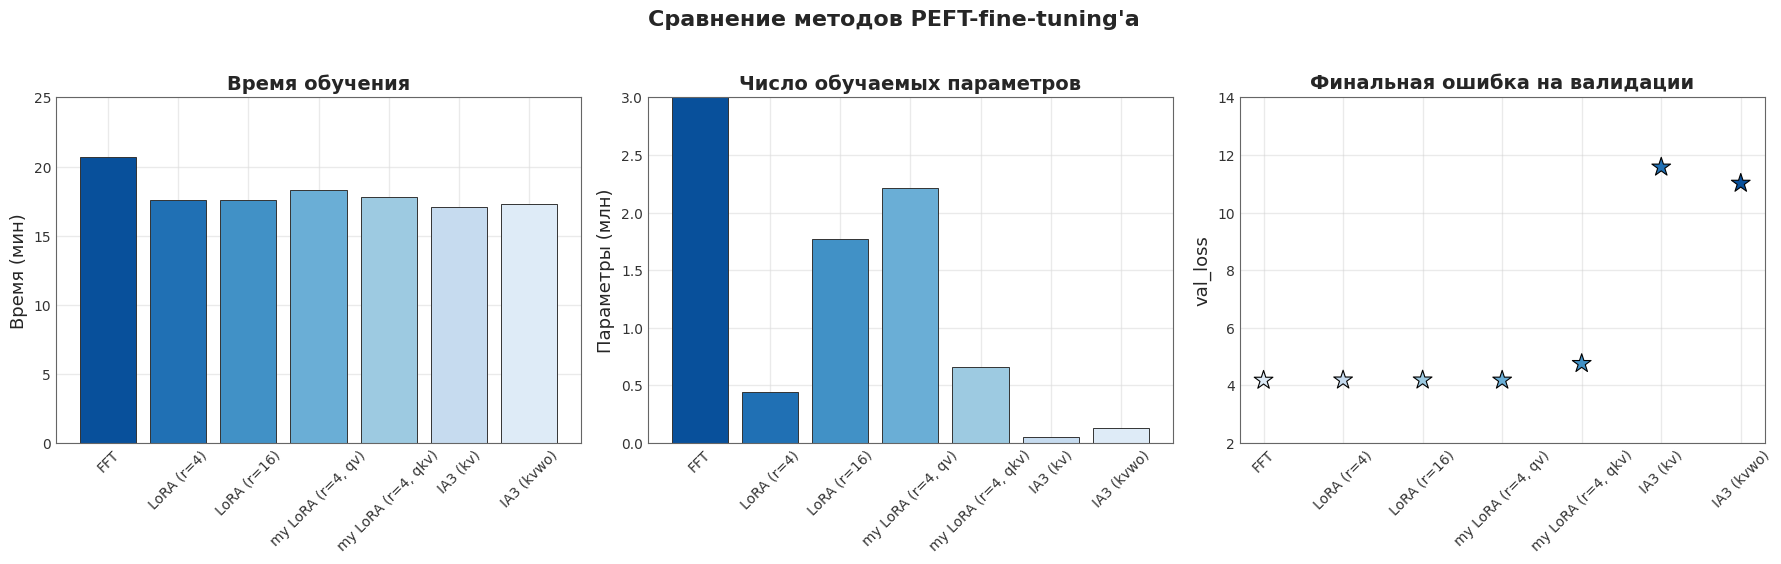

In [ ]:
df['params_million'] = df['all_trained_params'] / 1e6
df['train_time_min'] = df['train_time'] / 60

colors_time = sns.color_palette("Blues", n_colors=len(df))[::-1]
colors_params = sns.color_palette("Blues", n_colors=len(df))[::-1]
colors_loss = sns.color_palette("Blues", n_colors=len(df))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle("Сравнение методов PEFT-fine-tuning'а", fontsize=16, fontweight='bold', y=1.02)

# graph #1: T5ru-base fine-tuning time
bars_1 = axes[0].bar(df['model'], df['train_time_min'], color=colors_time, edgecolor='#333333', linewidth=0.7)
axes[0].set_title('Время обучения', fontweight='bold')
axes[0].set_ylabel('Время (мин)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 25)

# graph #2: number of trainable parameters during fine-tuning (without frozen ones)
bars_2 = axes[1].bar(df['model'], df['params_million'], color=colors_params, edgecolor='#333333', linewidth=0.7)
axes[1].set_title('Число обучаемых параметров', fontweight='bold')
axes[1].set_ylabel('Параметры (млн)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 3)

# graph #3: comparison of the final loss on validation after PEFT fine-tuning
x_pos = np.arange(len(df))
axes[2].scatter(x_pos, df['val_loss'], marker='*', s=200, color=colors_loss, edgecolor='black', linewidth=0.8, zorder=5)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(df['model'], rotation=45)
axes[2].set_title('Финальная ошибка на валидации', fontweight='bold')
axes[2].set_ylabel('val_loss')
axes[2].grid(True, linestyle='-', alpha=0.4, color='#cccccc')
axes[2].set_ylim(2, 14)

plt.tight_layout()
plt.savefig('model_comparison_style.png', dpi=300, bbox_inches='tight')
plt.show()

As a result, we retrained 7 models, namely: full fine-tuning, fine-tuning with the LoRA adapter on modules $q$ and $v$ and the scaling parameter $r = 4$ and $r = 16$, on my custom version of LoRA with $r = 4$ for modules $q$ and $v$, as well as for $q$, $v$, and $k$ simultaneously, as well as with the $IA^{3}$ gate adapter on modules $k$ and $v$, as well as for $k$, $v$, and $wo$ simultaneously. Due to a lack of sufficient resources, training was carried out for up to 2 epochs, and the results are presented in the graphs. The following can be said about them:

1) Unsurprisingly, the training time with full fine-tuning was the longest, taking around 20 minutes, while in the other cases, using PEFT methods, the training time was shorter, around 16-17 minutes – and this was only for two epochs! With more epochs, the difference would have been even greater, which is the advantage of using PEFT methods. It's also worth noting that custom versions of LoRA are slightly inferior to the library configurations of LoRA and $IA^{3}$, indicating that the library versions have certain technical optimizations.

2) It is also not surprising that the number of trainable parameters during full-fledged fine-tuning turns out to be colossally large - 296926464 parameters, and this does not include the frozen parameters of the original model. PEFT methods, on the other hand, allow one to significantly reduce the number of these parameters - LoRA does this by approximating matrices with output-input dimensions $r \ll d$, and $IA^{3}$ - by using specially trained vectors and a gate mechanism. As a result, LoRA with $r = 4$ and both versions of $IA^{3}$ lead to the training of a very small number of parameters - on the order of 50'000-600'000 parameters. It can also be noted that the number of trainable parameters for LoRA with $r = 16$ is approximately 4 times greater than with $r = 4$. This is logical, since LoRA reduces the number of trainable parameters from $\sim d^{2}$ to $\sim 2dr$, meaning that the number of trainable parameters changes linearly as $r$ changes. Finally, we note that the custom version of LoRA has a larger number of parameters with the same $r = 4$ and when injected onto the same $q$ and $v$ modules. Apparently, the peft version has some optimizations that we didn't take into account in our implementation. At the same time, the custom version with an additional adapter on the $k$-module has fewer parameters.

3) Finally, if we analyze the validation loss graph, we can see that, surprisingly, the best model is the one retrained with full fine-tuning. However, models retrained using PEFT methods also show comparable results ($loss\approx 4$), namely LoRA – both library and custom ones. This is an excellent result, as we combined efficiency with the same "ideal" FFT model performance. However, models with $IA^{3}$ blocks did not show the same results ($loss\approx 11$), despite accelerating the fine-tuning process. Their superiority is likely noticeable with a larger number of epochs or individually, depending on the specific task at hand.


#### 4. Model Evaluation

To evaluate the quality of summation, we will use the rouge class of metrics - this is an excellent option for assessing the quality of summation, since it allows us to estimate the overlap between the hypothetical and reference summation of unigrams, bigrams, trigrams, and so on, as well as the longest sequences, center-weighted windows, and more.

BLEU might also be a good option, but I'd prefer the former, as BLEU is less sensitive to text order. BERTScore, which tests quality based on the cosine similarity of the BERT embeddings of the hypothetical and reference summaries, could also be used. METEOR and chrF metrics are also possible, but they are still preferable for machine translation tasks.

In [ ]:
rouge = evaluate.load("rouge")
predictions = ["Предсказанный текст", "Ещё один текст"]
references = ["Истинный текст", "Снова один текст"]

results = rouge.compute(
    predictions=predictions, references=references, tokenizer=lambda x: x.split()
)
print(results)

{'rouge1': np.float64(0.5833333333333333), 'rouge2': np.float64(0.25), 'rougeL': np.float64(0.5833333333333333), 'rougeLsum': np.float64(0.5833333333333333)}


Let's choose `beam-search` as the decoding method with `nub_beams = 5`:

In [ ]:
gen_params = {
    "max_length": 256,
    "num_beams": 5,
    "no_repeat_ngram_size": 4,
    "early_stopping": True
}


And we will write a standard function for assessing the quality of the model:

In [ ]:
def eval_model(model, dataset, tokenizer):
    model.eval()
    predictions = []
    references = []

    time_start = time.time()

    device = next(model.parameters()).device

    for sample in tqdm(dataset):
        inputs = tokenizer(sample["text"], return_tensors="pt", truncation=True, max_length=600)
        input_ids = inputs.input_ids.to(device)
        attention_mask = inputs.attention_mask.to(device) if "attention_mask" in inputs else None

        with torch.no_grad():
            output_ids = model.generate(input_ids=input_ids, decoder_start_token_id=tokenizer.pad_token_id, **gen_params)

        predictions.append(tokenizer.decode(output_ids[0], skip_special_tokens=True))
        references.append(sample["summary"])

    time_finish = time.time() - time_start

    rouge_outputs = rouge.compute(
        predictions=predictions,
        references=references,
        tokenizer=lambda x: x.split()
    )

    return rouge_outputs, time_finish

Let's evaluate all the models and look at the metrics:

In [ ]:
all_models = [
    (model_fft, "FFT"),
    (model_LoRA_peft_4, "LoRA (r = 4)"),
    (model_LoRA_peft_16, "LoRA (r = 16)"),
    (model_LoRA_custom_qv, "custom LoRA (r = 4, on qv)"),
    (model_LoRA_custom_full, "custom LoRA (r = 4, on qkv)"),
    (model_IA3_kv, "IA3 (on kv)"),
    (model_IA3_kvwo, "IA3 (on kvwo)")
]

model_results_full = []

for model_, name in all_models:
    rouges, eval_time = eval_model(model_, val_dataset, tokenizer)

    model_results_full.append({
        "Модель": name,
        "Кол-во обучаемых параметров": train_params_cnt(model_),
        "Время, с": eval_time,
        "ROUGE-1": rouges["rouge1"],
        "ROUGE-2": rouges["rouge2"],
        "ROUGE-L": rouges["rougeL"],
        "ROUGE-Lsum": rouges["rougeLsum"]
    })


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

In [8]:
rouge_columns = [col for col in model_results_full.columns if col.startswith('ROUGE')]
df_rouge = model_results_full[['Модель'] + rouge_columns]

display(df_rouge)

,Модель,ROUGE-1,ROUGE-2,ROUGE-L,ROUGE-Lsum
0,FFT,0.2348,0.0971,0.1880,0.1878
1,LoRA (r = 16),0.2329,0.0956,0.1861,0.1859
2,LoRA (r = 4),0.2289,0.0932,0.1824,0.1822
3,"custom LoRA (r = 4, on qv)",0.2254,0.0913,0.1795,0.1793
4,"custom LoRA (r = 4, on qkv)",0.1874,0.0587,0.1370,0.1372
5,IA3 (on kv),0.0413,0.0019,0.0374,0.0375
6,IA3 (on kvwo),0.0486,0.0019,0.0335,0.0407


Based on the performance evaluation results of summation models trained in different ways, we can conclude that the quality drops significantly and leaves much to be desired. This is, understandably, due to the small number of epochs and the datasets being truncated for training and validation at the start to speed up the training process.

One notable point is that the results of models with $IA^{3}$ adapters have significantly lower autometrics than those for full fine-tuning and for models with LoRA adapters, which may be due to the low efficiency of using them with a small number of epochs.

It's also worth noting that the best results among the various ROUGE metrics are achieved by ROUGE-1, which searches for unigram matches. This seems to be a fairly common type of matching $N$-gram and is less indicative of the summarization task. While similar words can be retained, will there be any correlation? It's difficult to say anything about this based on this metric.

ROUGE-L and ROUGE-Lsum also yielded around $18\%$ on LoRA, where the former searches for matches across the largest matching sequences, while the latter searches for matches within sentences, after which it averages over the entire text. As we can see, they are practically identical, since matches covering several adjacent sentences should be rare. Nevertheless, these metrics can be considered more representative of the summation task, and we can assume that the average performance of our model on the ROUGE metric is around $18\%$.

#### 5. Comparison of models

Ilya Gusev actually has a [model](https://huggingface.co/IlyaGusev/rut5_base_sum_gazeta) that is trained on a similar task, so let's compare it with the best of the models I've looked at (which is FFT) using 2-3 real news examples:

In [ ]:
def get_summary(model, tokenizer, text):
    device = next(model.parameters()).device
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=600)
    input_ids = inputs.input_ids.to(device)
    attention_mask = inputs.attention_mask.to(device) if "attention_mask" in inputs else None

    with torch.no_grad():
        outputs = model.generate(input_ids=input_ids, **gen_params)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
model_name = "IlyaGusev/rut5_base_sum_gazeta"
tokenizer_ = AutoTokenizer.from_pretrained(model_name)
model_rut5_base_sum_gazeta = T5ForConditionalGeneration.from_pretrained(model_name)
my_best_model = model_fft

article_text_1 = "Появился ультимативный гайд по выживанию в Китае — твиттерский расписал главные приложения для страны, которые пропускают туристы. — Первым делом ставьте Alipay и проходите верификацию. Через него в Китае делается почти всё: оплата, такси, доставка, меню в кафе по QR-коду;— Навигацию удобнее вести через Amap: там можно сохранять адреса на китайском и просто показывать их водителям;— Такси проще всего вызывать прямо через Alipay или WeChat, а в аэропортах иногда нужно ещё объяснять водителю, у какого столба вы стоите;— Морально готовьтесь, что вас могут не понимать даже если вы говорите на... китайском. Поэтому адреса и названия мест лучше хранить в письменном виде на телефоне;— Во многих кафе на юге с этим максимально просто: сканируете QR-код, открывается меню, выбираете еду и платите вообще без общения с официантом;— Если не хочется экспериментировать, всегда есть международные сети вроде Pizza Hut, KFC и McDonald’s;— VPN лучше поставить заранее. Общий вывод: Китай может быть ультракомфортным и дешёвым, если вы встроились в местную экосистему приложений. Если нет — легко почувствовать себя человеком, которого высадили на другой планете."
article_text_2 = "Министерство сельского хозяйства Саратовской области прокомментировало наблюдаемый в регионе рост цен на куриное яйцо. Как полагают чиновники, это связано с увеличившимся сезонным спросом и некоторыми другими факторами.Напомним, по итогам проведенного Саратовстатом мониторинга цен за прошлую неделю оказалось, что яйца куриные выросли в цене на 2,82%, а на позапрошлой - на 4,28%.В минсельхозе заверяют, что предприятия региона полностью обеспечивают потребности жителей по данной продуктовой группе – обеспеченность превышает потребность в два раза.Действительно, с конца февраля наблюдается тенденция к сезонному увеличению стоимости товарного яйца, что обусловлено ростом себестоимости производства, в том числе затрат на сырье для комбикормов и логистику, а также повышением спроса в предпасхальный период, - объясняют чиновники в тг-канале министерства.По их сведениям, в производстве продукции птицеводства в регионе наблюдается устойчивый рост. Так, по итогам 2025 года в области произведено 1,2 млрд штук яиц, что на 20% выше уровня позапрошлого года."
article_text_3 = "🐍 Вышла новая модель из серии Mamba - Mamba-3.Гибридные архитектуры становятся всё популярнее, поэтому всё больше внимания уделяется созданию следующего поколения линейных моделей.В Mamba-3 исследователи предложили несколько новых идей вокруг SSM (state space models), которые заметно увеличивают способность модели обучаться без потери скорости.В результате Mamba-3 показывает более высокую производительность, чем предыдущие линейные модели, включая:- Mamba-2- Gated DeltaNetПричём улучшения наблюдаются во всех размерах моделей.Интересный факт:  это первая версия Mamba, созданная студентами.Что нового в Mamba-3: 1. Улучшенная дискретизация SSM Предложена новая схема дискретизации, которая лучше имитирует свёртку (convolution) и делает модель более выразительной. Она также позволила избавиться от short convolution, который раньше использовался в линейных моделях. 2. Комплексные переходы состояний Переходы состояний теперь используют комплексные числа, что значительно улучшает способность модели отслеживать состояние. Это решает проблемы предыдущих версий Mamba, которые, например, не могли решать даже некоторые простые задачи вроде bit parity. 3. Архитектура MIMO вместо SISO Модель перешла от структуры SISO (single input single output) к MIMO (multiple input multiple output). Это позволяет лучше использовать железо при inference, что даёт дополнительный прирост производительности.Также архитектура была немного обновлена и стала ближе к современным языковым моделям. Например, добавлены компоненты вроде BC / QK normalization. Mamba-3 заметно усиливает линейные модели и делает их ещё более конкурентными с трансформерами, особенно в задачах языкового моделирования."
articles = [article_text_1, article_text_2, article_text_3]

summaries_rut5_base_sum_gazeta = [get_summary(model_rut5_base_sum_gazeta, tokenizer_, article) for article in articles]
summaries_my_best_model = [get_summary(my_best_model, tokenizer, article) for article in articles]


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
comp_df = pd.DataFrame({
    "source": articles,
    "pretrained (IlyaGusev/rut5_base_sum_gazeta)": summaries_rut5_base_sum_gazeta,
    "my best fine-tuned model": summaries_my_best_model
}, index=["Пример 1", "Пример 2", "Пример 3"])

pd.set_option('display.max_colwidth', None)
display(comp_df)

,source,pretrained (IlyaGusev/rut5_base_sum_gazeta),my best fine-tuned model
Пример 1,"Появился ультимативный гайд по выживанию в Китае — твиттерский расписал главные приложения для страны, которые пропускают туристы. — Первым делом ставьте Alipay и проходите верификацию. Через него в Китае делается почти всё: оплата, такси, доставка, меню в кафе по QR-коду;— Навигацию удобнее вести через Amap: там можно сохранять адреса на китайском и просто показывать их водителям;— Такси проще всего вызывать прямо через Alipay или WeChat, а в аэропортах иногда нужно ещё объяснять водителю, у какого столба вы стоите;— Морально готовьтесь, что вас могут не понимать даже если вы говорите на... китайском. Поэтому адреса и названия мест лучше хранить в письменном виде на телефоне;— Во многих кафе на юге с этим максимально просто: сканируете QR-код, открывается меню, выбираете еду и платите вообще без общения с официантом;— Если не хочется экспериментировать, всегда есть международные сети вроде Pizza Hut, KFC и McDonald’s;— VPN лучше поставить заранее. Общий вывод: Китай может быть ультракомфортным и дешёвым, если вы встроились в местную экосистему приложений. Если нет — легко почувствовать себя человеком, которого высадили на другой планете.","Китай может быть ультракомфортным и дешёвым, если встроились в экосистему приложений для страны, которые пропускают туристы. В твиттере появился ультимативный гайд по выживанию в Китае.",и иin repair<0x1F><0x03> груд<0x0A><0x01>
Пример 2,"Министерство сельского хозяйства Саратовской области прокомментировало наблюдаемый в регионе рост цен на куриное яйцо. Как полагают чиновники, это связано с увеличившимся сезонным спросом и некоторыми другими факторами.Напомним, по итогам проведенного Саратовстатом мониторинга цен за прошлую неделю оказалось, что яйца куриные выросли в цене на 2,82%, а на позапрошлой - на 4,28%.В минсельхозе заверяют, что предприятия региона полностью обеспечивают потребности жителей по данной продуктовой группе – обеспеченность превышает потребность в два раза.Действительно, с конца февраля наблюдается тенденция к сезонному увеличению стоимости товарного яйца, что обусловлено ростом себестоимости производства, в том числе затрат на сырье для комбикормов и логистику, а также повышением спроса в предпасхальный период, - объясняют чиновники в тг-канале министерства.По их сведениям, в производстве продукции птицеводства в регионе наблюдается устойчивый рост. Так, по итогам 2025 года в области произведено 1,2 млрд штук яиц, что на 20% выше уровня позапрошлого года.","Министерство сельского хозяйства Саратовской области прокомментировало рост цен на куриное яйцо. Как считают чиновники, это связано с увеличившимся сезонным спросом и некоторыми другими факторами. По их словам, яйца куриные выросли в цене на 2,82%, а на позапрошлой - на 4,28%.",<0x0D><0x38>ется<0x03><0xF8><0x16>
Пример 3,"🐍 Вышла новая модель из серии Mamba - Mamba-3.Гибридные архитектуры становятся всё популярнее, поэтому всё больше внимания уделяется созданию следующего поколения линейных моделей.В Mamba-3 исследователи предложили несколько новых идей вокруг SSM (state space models), которые заметно увеличивают способность модели обучаться без потери скорости.В результате Mamba-3 показывает более высокую производительность, чем предыдущие линейные модели, включая:- Mamba-2- Gated DeltaNetПричём улучшения наблюдаются во всех размерах моделей.Интересный факт: это первая версия Mamba, созданная студентами.Что нового в Mamba-3: 1. Улучшенная дискретизация SSM Предложена новая схема дискретизации, которая лучше имитирует свёртку (convolution) и делает модель более выразительной. Она также позволила избавиться от short convolution, который раньше использовался в линейных моделях. 2. Комплексные переходы состояний Переходы состояний теперь используют комплексные числа, что значительно улучшает способность модели отслеживать состояние. Это решает проблемы предыдущих версий Mamba, которые, например, не могли решать даже некоторые прост

As we can see, the pre-trained model `IlyaGusev/rut5_base_sum_gazeta` produces a very high-quality summarization of the original news items, and there's really nothing more to say.

Our model, however, fails to perform the summarization task, which was clear from the low ROUGE metric: the result contains unreadable characters, fragments of words, jumbled Russian and English words, and simply strange, meaningless letter combinations. Clearly, to achieve more or less decent results, the model should have been trained on a much larger number of epochs, perhaps using different decoding methods and generation parameters.

However, the goal was to use PEFT methods for fine-tuning large models. We have verified the effectiveness of methods such as the LoRA and $(IA)^{3}$ adapters.